# HBV hydrological model forced with ERA5 forcing data
In this notebook we will generate forcing data for the HBV hydrological model from the output of a CMIP6 climate model using the eWaterCycle platform. Here we generate forcing data for different future climate scenarios. 

The code in this notebook is nearly identical to the code in [this notebook](step_1a_generate_historical_forcing.ipynb) where we generated both ERA5 and historical CMIP6 forcing data. For detailed descriptions, see that notebook.

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import json
from esmvalcore.config import CFG
import shutil

# Niceties
from rich import print

# DestinE stuff
# This will work normally for HPC
try:
    from scripts.forcing_destine import DestinEFutureForcing
except ImportError:
    # Add the project root to Python path for use on SRC
    project_root = Path().resolve().parent
    sys.path.append(str(project_root))
    
    from scripts.forcing_destine import DestinEFutureForcing


In [2]:
# General eWaterCycle
import ewatercycle
import ewatercycle.forcing

In [3]:
# Parameters, these get changed when running on HPC
# country = "australia"
# region_id = "camelsaus_102101A"
settings_path = "settings.json"

In [4]:
# Parameters
settings_path = "regions/mexico/hysets_10034/settings.json"


In [5]:
# Load settings
# Read from the JSON file
with open(settings_path, "r") as json_file:
    settings = json.load(json_file)

In [6]:
display(settings)

{'caravan_id': 'hysets_10034',
 'country': 'mexico',
 'calibration_start_date': '1994-08-01T00:00:00Z',
 'calibration_end_date': '2004-07-31T00:00:00Z',
 'validation_start_date': '2004-08-01T00:00:00Z',
 'validation_end_date': '2014-07-31T00:00:00Z',
 'future_start_date': '2029-08-01T00:00:00Z',
 'future_end_date': '2049-08-31T00:00:00Z',
 'CMIP_info': {'dataset': ['MPI-ESM1-2-LR'],
  'ensembles': ['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'],
  'experiments': ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585'],
  'project': 'CMIP6',
  'grid': 'gn'},
 'koppen_raster_path': '/home/ewater-mmelotto/koppen_geiger/1991_2020/koppen_geiger_0p00833333.tif',
 'base_path': '/project/ewater/Data/ewatercycleClimateImpact/HBV',
 'path_caravan': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/caravan',
 'path_ERA5': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/ERA5',
 'path_DestinE': '/project/ewater/Data/ewatercycleClimateImpact/H

## CMIP future forcing
We loop over the different datasets, experiments and ensembles, but we skip the first experiment, which is the 'historical' one, this was already done in [this notebook](step_1a_generate_historical_forcing.ipynb).

In [7]:
# Setting for ESMValTool to make sure the online esgf resources are always used and
# we don't rely on locally cached information.
# CFG['search_esgf'] = 'when_missing'
CFG['search_esgf'] = 'always'
CFG['rootpath'] = {'CMIP6': [Path(settings['path_CMIP6'])], 'default': [Path(settings['path_output'])]}
CFG['download_dir'] = settings['downloads']
display(CFG)

Config({'auxiliary_data_dir': PosixPath('/home/ewater-mmelotto/auxiliary_data'),
        'check_level': <CheckLevels.DEFAULT: 3>,
        'compress_netcdf': False,
        'config_developer_file': PosixPath('/home/ewater-mmelotto/miniforge3/envs/ewatercycle_spider/lib/python3.12/site-packages/esmvalcore/config-developer.yml'),
        'config_file': PosixPath('/home/ewater-mmelotto/miniforge3/envs/ewatercycle_spider/lib/python3.12/site-packages/esmvalcore/config-user.yml'),
        'diagnostics': None,
        'download_dir': PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/downloads/hysets_10034'),
        'drs': {'CMIP3': 'ESGF',
                'CMIP5': 'ESGF',
                'CMIP6': 'ESGF',
                'CORDEX': 'ESGF',
                'obs4MIPs': 'ESGF'},
        'exit_on_warning': False,
        'extra_facets_dir': (),
        'log_level': 'info',
        'max_datasets': None,
        'max_parallel_tasks': None,
        'max_years': None,
        'output_dir': P

'MPI-ESM1-2-LR'

'ssp126'

'r1i1p1f1'

LumpedMakkinkForcing(start_time='2029-08-01T00:00:00Z', end_time='2049-08-31T00:00:00Z', directory=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/CMIP6/MPI-ESM1-2-LR/ssp126/r1i1p1f1/work/diagnostic/script'), shape=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/caravan/hysets_10034.shp'), filenames={'pr': 'CMIP6_MPI-ESM1-2-LR_day_ssp126_r1i1p1f1_pr_gn_2029-2049.nc', 'tas': 'CMIP6_MPI-ESM1-2-LR_day_ssp126_r1i1p1f1_tas_gn_2029-2049.nc', 'rsds': 'CMIP6_MPI-ESM1-2-LR_day_ssp126_r1i1p1f1_rsds_gn_2029-2049.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.


...

LumpedMakkinkForcing(start_time='2029-08-01T00:00:00Z', end_time='2049-08-31T00:00:00Z', directory=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/CMIP6/MPI-ESM1-2-LR/ssp585/r2i1p1f1/work/diagnostic/script'), shape=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/caravan/hysets_10034.shp'), filenames={'pr': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r2i1p1f1_pr_gn_2029-2049.nc', 'tas': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r2i1p1f1_tas_gn_2029-2049.nc', 'rsds': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r2i1p1f1_rsds_gn_2029-2049.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.


'r3i1p1f1'

LumpedMakkinkForcing(start_time='2029-08-01T00:00:00Z', end_time='2049-08-31T00:00:00Z', directory=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/CMIP6/MPI-ESM1-2-LR/ssp585/r3i1p1f1/work/diagnostic/script'), shape=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/caravan/hysets_10034.shp'), filenames={'pr': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r3i1p1f1_pr_gn_2029-2049.nc', 'tas': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r3i1p1f1_tas_gn_2029-2049.nc', 'rsds': 'CMIP6_MPI-ESM1-2-LR_day_ssp585_r3i1p1f1_rsds_gn_2029-2049.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'})

/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/tmp/ipykernel_321398/989959065.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.


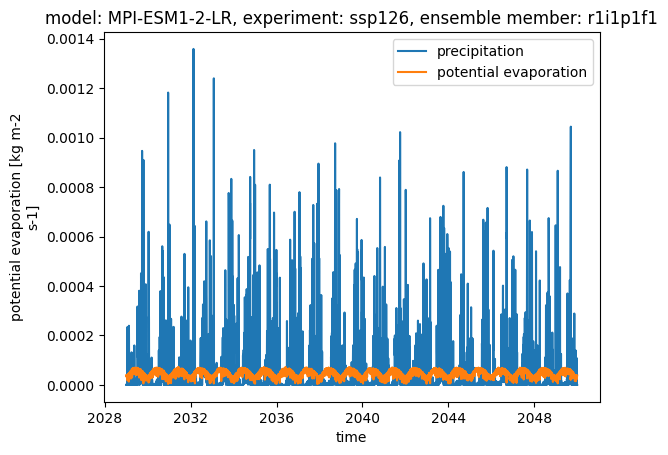

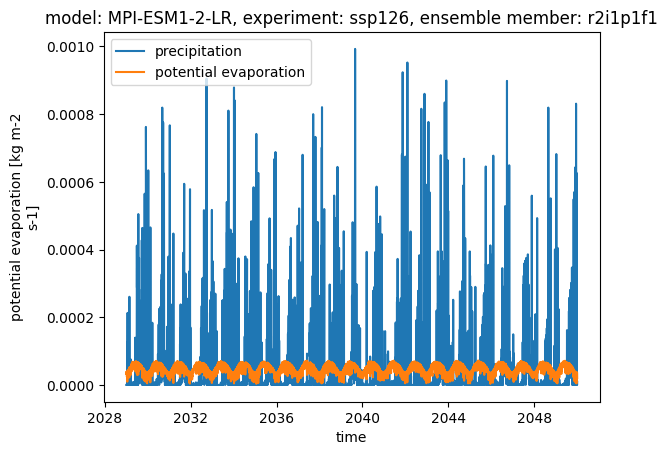

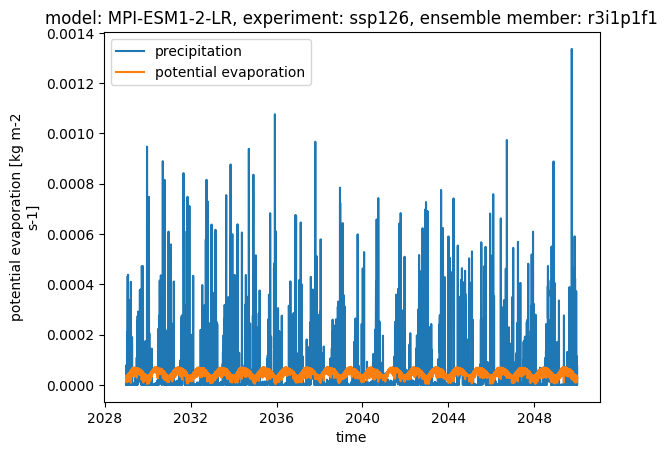

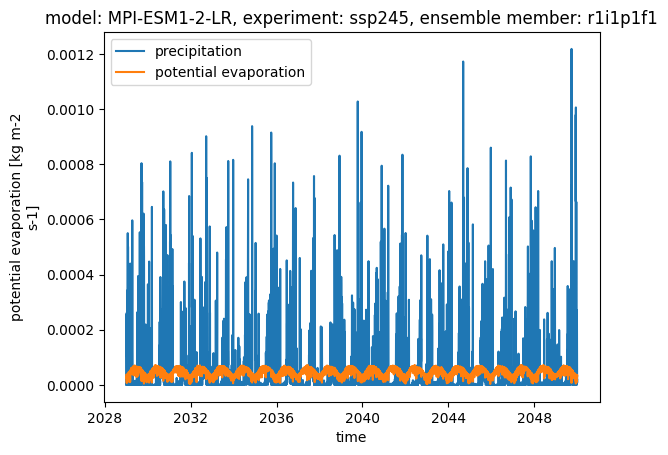

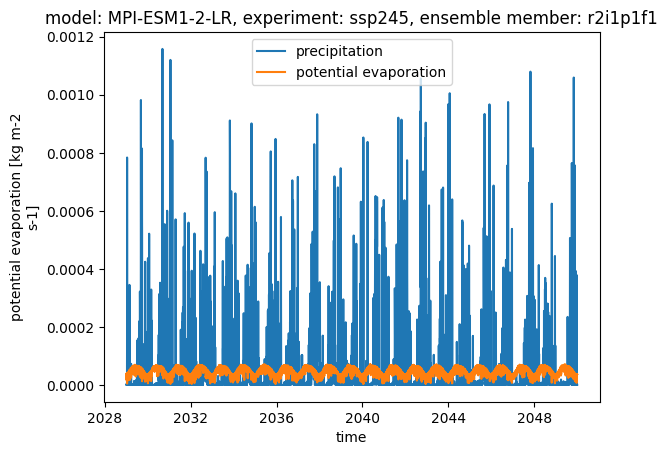

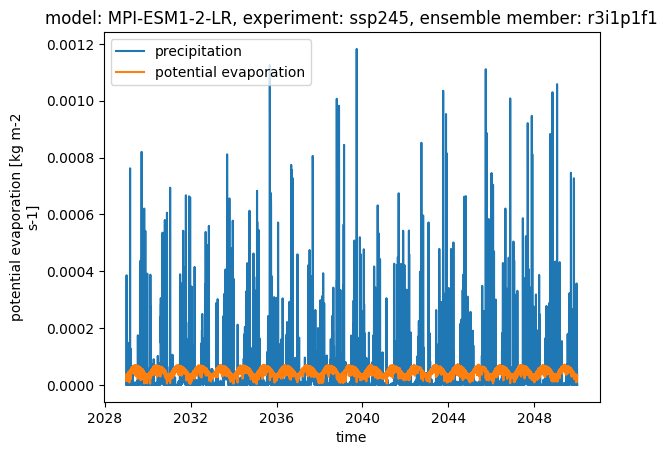

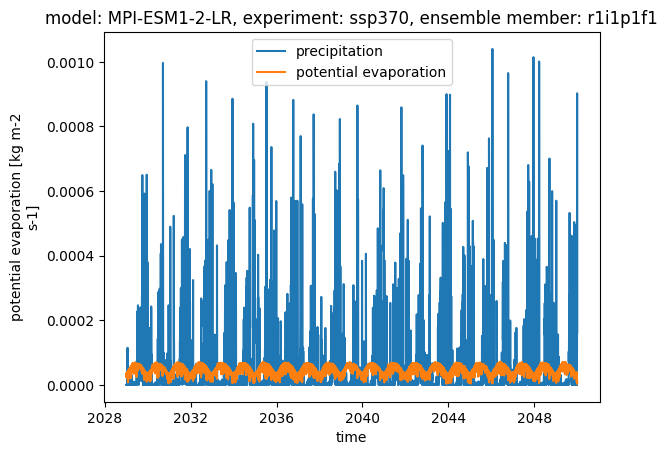

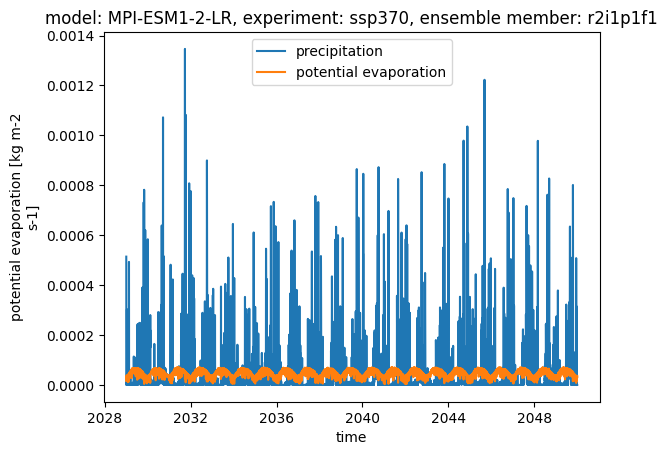

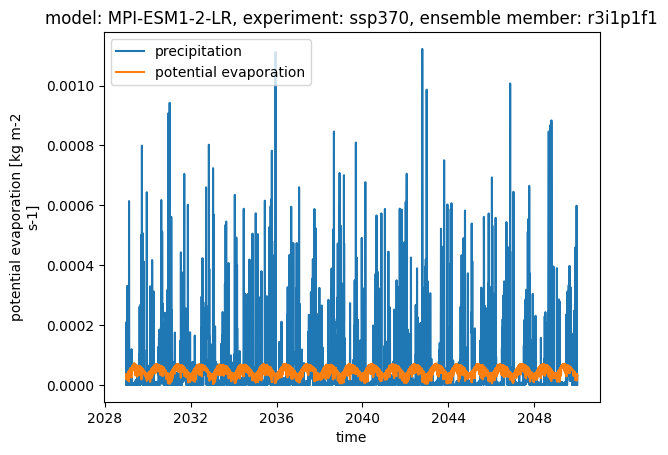

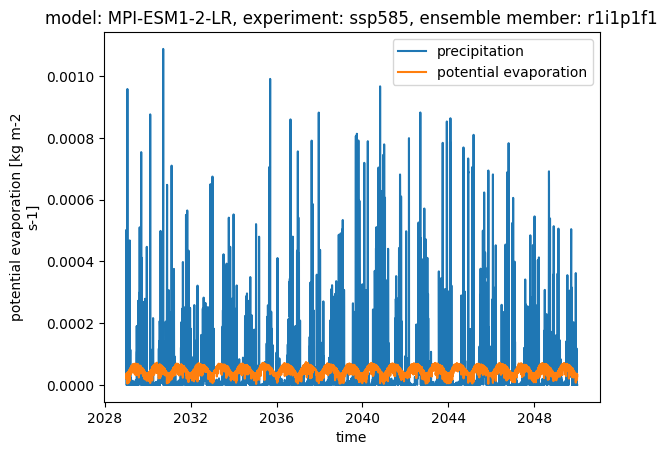

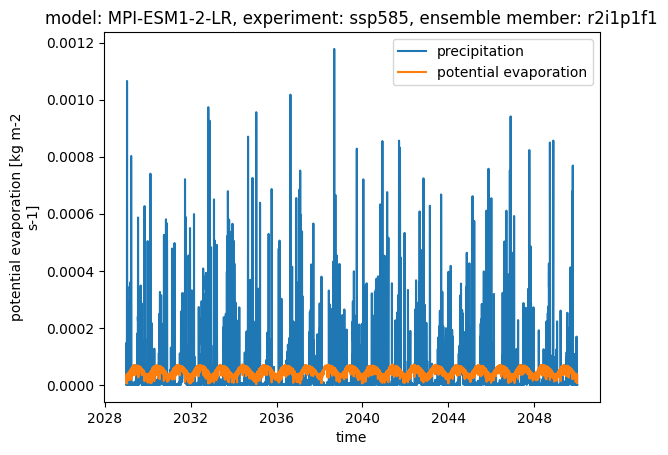

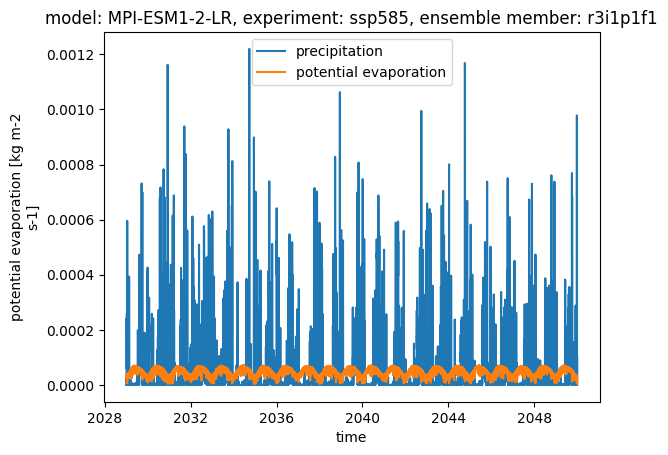

In [8]:
for dataset_name in settings['CMIP_info']['dataset']: 
    # We are asuming one dataset, but this loop allows for multiple
    display(dataset_name)
    
    for experiment_name in settings['CMIP_info']['experiments'][1:]: # skipping historical
        display(experiment_name)
    
        for ensemble_name in settings['CMIP_info']['ensembles']:
            display(ensemble_name)

            cmip_dataset = {
                "dataset": dataset_name,
                "project": settings['CMIP_info']['project'],
                "grid": "gn",
                "exp": experiment_name,
                "ensemble": ensemble_name,
            }
        
            # Create a subfolder for this specific combination of dataset, experiment and ensemblemember
            path_CMIP6 = Path(settings['path_CMIP6']) / cmip_dataset["dataset"] / cmip_dataset["exp"] / cmip_dataset["ensemble"]
            # path_CMIP6.mkdir(exist_ok=True, parents=True)

            try:
                load_location = path_CMIP6 / "work" / "diagnostic" / "script" 
                CMIP_forcing_object = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
            except:
                if path_CMIP6.exists():
                    shutil.rmtree(path_CMIP6)
                path_CMIP6.mkdir(exist_ok=True, parents=True)
                CMIP_forcing_object = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
                   dataset=cmip_dataset,
                   start_time=settings['future_start_date'],
                   end_time=settings['future_end_date'],
                   directory=path_CMIP6,
                   shape=settings['path_shape'],
                )
            display(CMIP_forcing_object)

            # Quick plot of the precipitation and potential evaporation data
            plt.figure()
            ds_CMIP = xr.open_mfdataset([CMIP_forcing_object['pr'],CMIP_forcing_object['evspsblpot']])
            ds_CMIP["pr"].plot(label = 'precipitation')
            ds_CMIP["evspsblpot"].plot(label = 'potential evaporation')
            plt.legend()
            plt.title('model: ' + dataset_name + ', experiment: ' + experiment_name + 
                      ', ensemble member: ' + ensemble_name) 

## DestinE SSP370 future forcing

The DestinE Digital Twin for Climate Change Adaptation (Climate DT) supports adaptation activities by providing innovative climate information on multi-decadal timescales, globally, at scales at which many impacts of climate change are observed. It combines cutting-edge global Earth-system models, impact-sector applications and observations into a unified framework to provide global climate projections and impact-sector information on multi-decadal timescales (1990 to ~2050), at very high spatial resolutions (5 to 10 km). The data from the first prototype projections is already available through the DestinE platform for users with upgraded access. 

eWaterCycle is in partnership with project DestinE, and this is placeholder function. We are working with ESMValTool to facilitate working with the zarr data that DestinE provides.

In [9]:
%%capture cap
try:
    %run scripts/desp-authentication.py
except:
    %run ../scripts/desp-authentication.py

In [10]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

Polygon simplified to 200 points (tolerance=0.0010 deg)
Data is split up in parts
Running 1 of 21
start = '20290801'
end = '20291231'


2026-04-16 10:34:23 - INFO - Key read from /home/ewater-mmelotto/.polytopeapirc


2026-04-16 10:34:23 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20290801/to/20291231\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            'feature:\n'
            '  shape:\n'
            '  - - 26.052869493999026\n'
            '    - -108.30612674718223\n'
            '  - - 26.059405070758707\n'
            '    - -108.30710676874502\n'
            '  - - 26.063834663862274\n'
            '    - -108.30431251158664\n'
            '  - - 26.070136882773625\n'
            '    - -108.30355679483931\n'
            '  - - 26.07244916517976\n'
            '    - -108.30019779262784\n'
            '  - - 26.07548607122027\n'
            '    - -108.29939701171666\n'
            '  - - 26.082276910907975\n'
            '    - -108.30257355226478\n'
            '  - - 26.087750611807277\n'
            '    - -108.2992939293419\n'
            '  - - 26.09303930

2026-04-16 10:34:23 - INFO - Polytope user key found in session cache for user ewater-mmelotto


2026-04-16 10:34:24 - INFO - Request accepted. Please poll ./496fbc84-98a6-4a1a-9760-0d3f764c0406 for status


...

107edfda-2d95-4178-b08a-bd24030edbcb.covjson:   0%|          | 0.00/5.82M [00:00<?, ?B/s]

107edfda-2d95-4178-b08a-bd24030edbcb.covjson:  17%|█▋        | 1.00M/5.82M [00:00<00:02, 2.05MB/s]

Concatenating all windows...


LumpedMakkinkForcing(start_time='2029-08-01T00:00:00Z', end_time='2049-08-31T00:00:00Z', directory=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/DestinE'), shape=PosixPath('/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/caravan/hysets_10034.shp'), filenames={'pr': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/DestinE/DestinE_future_day_pr_2029_08_01-2049_08_31.nc', 'tas': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/DestinE/DestinE_future_day_tas_2029_08_01-2049_08_31.nc', 'rsds': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/DestinE/DestinE_future_day_rsds_2029_08_01-2049_08_31.nc', 'evspsblpot': '/project/ewater/Data/ewatercycleClimateImpact/HBV/forcing_data/mexico/hysets_10034/DestinE/DestinE_future_day_evspsblpot_2029_08_01-2049_08_31.nc'})

Text(0.5, 1.0, 'model: DestinE SSP370')

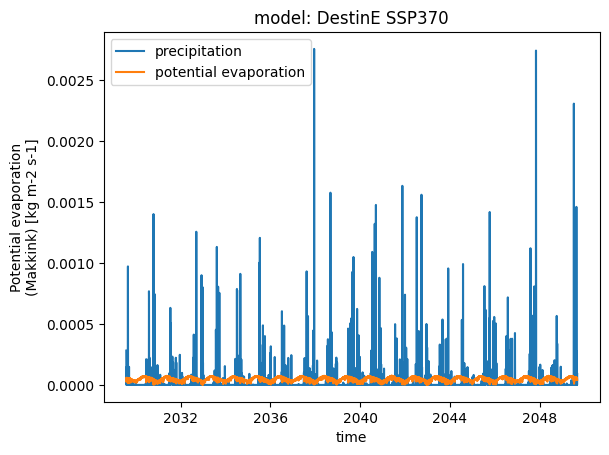

In [11]:
# Generate forcing:
try:
    DestinE_forcing_object = DestinEFutureForcing.load(settings['path_DestinE'])
except:
    DestinE_forcing_object = DestinEFutureForcing.generate(
       start_time=settings['future_start_date'],
       end_time=settings['future_end_date'],
       directory=settings['path_DestinE'],
       shape=settings['path_shape'],
    )

display(DestinE_forcing_object)

# Quick plot of the precipitation and potential evaporation data
plt.figure()
ds_DestinE = xr.open_mfdataset([DestinE_forcing_object['pr'],DestinE_forcing_object['evspsblpot']])
ds_DestinE["pr"].plot(label = 'precipitation')
ds_DestinE["evspsblpot"].plot(label = 'potential evaporation')
plt.legend()
plt.title('model: DestinE SSP370') 